**<u>THEORY PART AND INFO ABOUT SCIKIT-LEARN<u>**

Its a free library that provides tools used for:
* Data processing
* Model selection
* Classification 
* Clusering
* Regression
* Evaluation

Its built on `NumPy`, `SciPy` and `Matplotlib`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris # Load the Iris dataset
from sklearn.model_selection import train_test_split # Split the dataset into training and testing sets
from sklearn.linear_model import LogisticRegression # Import the Logistic Regression model
from sklearn.metrics import accuracy_score # Import the accuracy_score function to evaluate the model's performance
import sklearn.datasets # Import the datasets module from scikit-learn to load the Iris dataset

It provides several built-in datasets, such as the Iris dataset, which is a classic classification problem.

The Iris dataset is one of the most famous and widely used datasets in statistics and machine learning. It was introduced by the British statistician Ronald A. Fisher in 1936, and is often used as a beginner's dataset for classification tasks.

* Samples: 150 observations (rows)
* Features: 4 numerical attributes (columns)
* Target: 3 different species of the Iris flower

Each sample belongs to one of three species:

* 0: Iris Setosa
* 1: Iris Versicolor
* 2: Iris Virginica

These are stored in the target array of the dataset.

Each flower is described by four measurements (in centimeters):
* Sepal length
* Sepal width
* Petal length
* Petal width

These are stored in the data array (or `df[iris.feature_names]` if converted to a DataFrame).

In [2]:
iris = load_iris() # Load the Iris dataset into a variable called 'iris'
df = pd.DataFrame(iris.data, columns=iris.feature_names) # Create a DataFrame from the Iris dataset's data
df['target'] = iris.target # Add a new column to the DataFrame called 'target'

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


Bunch objects are sometimes used as an output for functions and methods. They extend dictionaries by enabling values to be accessed by key, `bunch["value_key"]`, or by an attribute, `bunch.value_key`.

**Scatter plot**

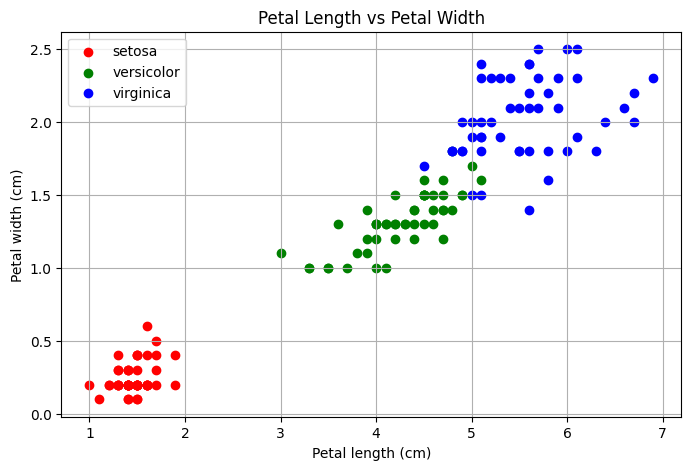

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()

x = iris.data[:, 2]  # petal length
y = iris.data[:, 3]  # petal width

labels = iris.target
species = iris.target_names

plt.figure(figsize=(8, 5)) # Set the figure size for better visibility

plt.scatter(x[labels == 0], y[labels == 0], label=species[0], color='red') # Scatter plot for the first species (setosa) in red
plt.scatter(x[labels == 1], y[labels == 1], label=species[1], color='green') # Scatter plot for the second species (versicolor) in green
plt.scatter(x[labels == 2], y[labels == 2], label=species[2], color='blue') # Scatter plot for the third species (virginica) in blue

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.grid(True) # Add a grid for better readability
plt.show()

**Split the dataset**

We use `train_test_split()` to divide the data into:
* Training set (used to train the model)
* Test set (used to evaluate how well the model generalizes)

In [4]:
X = df[iris.feature_names] # Select the feature columns from the DataFrame and assign them to variable 'X'
y = df['target'] # Select the target column from the DataFrame and assign it to variable 'y'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Split the dataset into training and testing sets, with 20% of the data reserved for testing and a random state for reproducibility

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (120, 4)
Test set size: (30, 4)


**Train a ML model**

We will use a `Logistic Regression` classifier from `sklearn.linear_model`. This is a simple and effective algorithm for classification problems.

In [5]:
model = LogisticRegression(max_iter=200) # Create an instance of the Logistic Regression model with a maximum of 200 iterations
model.fit(X_train, y_train) # Fit the model to the training data (X_train and y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

After training, we use the model to predict labels for the test set and compute the accuracy score.

In [6]:
y_pred = model.predict(X_test) # Use the trained model to make predictions on the test set

print("Predictions:", y_pred)
print("True labels:", y_test.values)

accuracy = accuracy_score(y_test, y_pred) # Calculate the accuracy of the model by comparing the true labels with the predicted labels
print("Accuracy:", accuracy)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
True labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0


**Logistic regression**

Logistic Regression is a widely used machine learning algorithm for binary and multiclass classification. Despite its name, it is not a regression algorithm, but a classification model based on probabilities.

It works by estimating the probability that a given input belongs to a certain class, using the logistic (sigmoid) function.

Logistic Regression learns the optimal values of the weights (`w`) and bias (`b`) by minimizing a specific cost function.

The model aims to find `w` and `b` such that the predicted probabilities are as close as possible to the true class labels (0 or 1).

The most common loss function used in logistic regression is the log loss.

To minimize the loss, the algorithm uses an iterative optimization algorithm such as:
* Gradient Descent
* Stochastic Gradient Descent (SGD)
* LBFGS or liblinear (used in scikit-learn)

These algorithms update the weights w and bias b step by step until the loss converges.

**Synthesis**

Logistic Regression is trained by:

1. Defining a loss function (log loss)
2. Using an optimization algorithm to find the weights `w` and bias `b` that minimize the loss
3. Making predictions using the learned parameters